In [1]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

In [2]:
mutants = ['wt', 'N214A', 'Q256A', 'S284A']
mutant_colors  = ['k', 'b', 'g', 'orange']

ks_s = [
        KineticsSeries('./wt/wt.yaml', corrections='./config.yaml', prefix='./wt'),
        KineticsSeries('./N214A/n214a.yaml', corrections='./config.yaml', prefix='./N214A'),
        KineticsSeries('./Q256A/q256a.yaml', corrections='./config.yaml', prefix='./Q256A'),
        KineticsSeries('./S284A/s284a.yaml', corrections='./config.yaml', prefix='./S284A'),
       ]

#    ks = KineticsSeries('./wt_dmso/wt_dmso.yaml', corrections='./config.yaml', prefix='./wt_dmso')

ps = [2.0, 5.0, 10.0, 20.0, 40.0, 80.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

Loading: 210401_2µM_MproWT.csv...
 ... excluded
Loading: 210401_buffer_200µM_MproWT.csv...
 ... excluded
Loading: 210413_02_002µM_MproWT.csv...
 ... excluded
Loading: 210413_buffer_2µM_MproWT.csv...
 ... excluded
Loading: 210420_20µM_MproWT.csv...
 ... excluded
Loading: 210420_10µM_MproWT.csv...
 ... excluded
Loading: 210420_5_and_2µM_MproWT.csv...
 ... excluded
Loading: 210430_20_10_5_and_2µM_MproWT.csv...
Loading: 210430_buffer_160_80_and_40µM_MproWT.csv...
 ... excluding E=160.00 / S=160.00
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210414_20_2_02_002µM_MproN214A.csv...
 ... excluded
Loading: 210421_20_and_10_µM_MproN214A.csv...
 ... excluded
Loading: 210421_5_and_2_µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A.csv...
Loading: 210427_buffer_160_and_80µM_MproN214A_2.csv...
Loading: 210427_40_20_and_10µM_MproN214A.csv...
 ... excluding E=20.00 / S=20.00
 ... excluding E

In [3]:
for ks in ks_s:
    ks.fit_v0(r2_threshold=0.0)

<IPython.core.display.Javascript object>


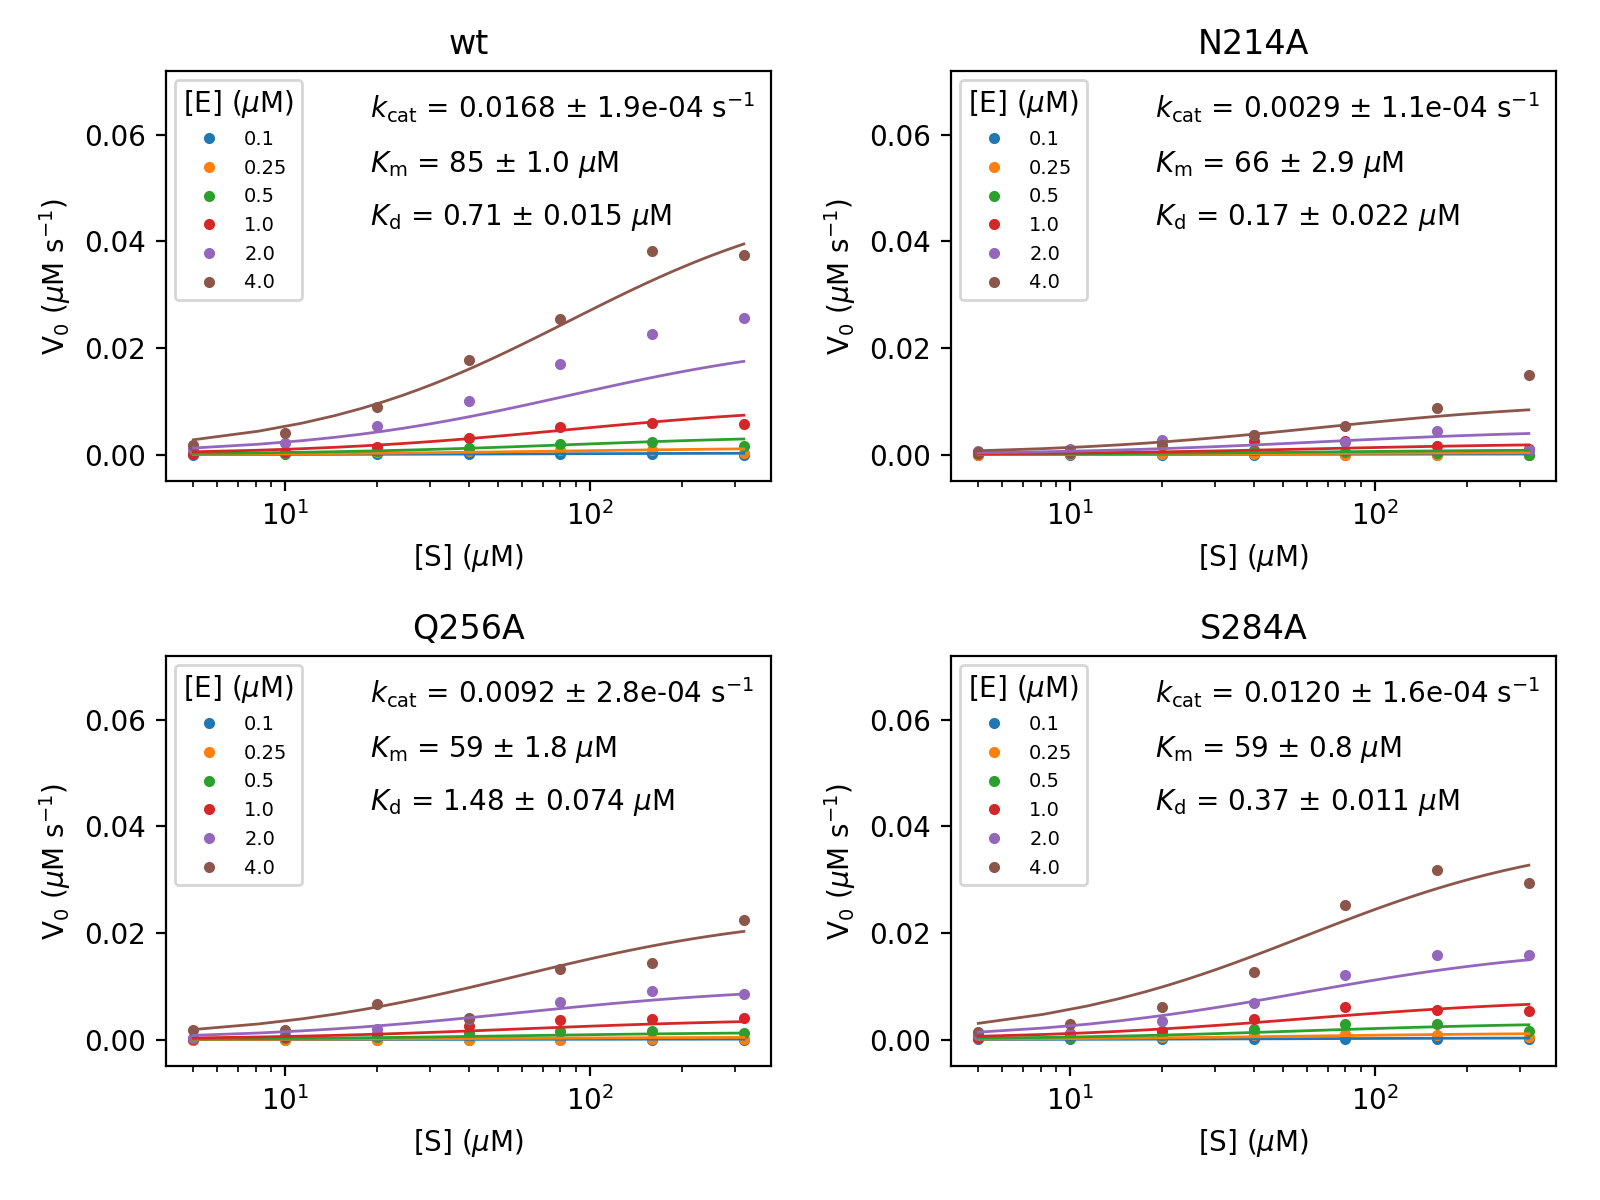

In [4]:
S = np.linspace(ss.min(), ss.max(), 100)

fig, axes = plt.subplots(2, 2, figsize=(8,6))

for im, m in enumerate(mutants):
    
    ks = ks_s[im]

    ax = axes[ im//2, im%2 ]
    ax.set_title(m)

    # fit to dimer activity model
    s0s, p0s, v0s, v0errs = ks.get_set_v0s(ps, ss)
    
    # there is an issue with some fits failing
    # and the errors are set to zero -- discard these
    good = (v0errs != 0.0)
    s0s = s0s[good]
    p0s = p0s[good]
    v0s = v0s[good]
    v0errs = v0errs[good]

    # parameters: k_cat, K_m, K_d
    popt, perr = fit_mm_dimer(v0s, s0s, p0s / 20.0, v0errs=v0errs)
    for i,p in enumerate(ps):
        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
        ax.plot(s0s, v0s, '.')

    ax.set_prop_cycle(None)
    for i,p in enumerate(ps):
        V_fit = mm_dimer( p / 20.0, S, *popt)
        ax.plot(S, V_fit, lw=1)

    x_pos = 19
    y_pos = 0.043
    ax.text(x_pos, y_pos + 0.02, '$k_{\mathrm{cat}}$ = %.4f $\pm$ %.1e s$^{-1}$' % (popt[0], perr[0]))
    ax.text(x_pos, y_pos + 0.01, '$K_{\mathrm{m}}$ = %.0f $\pm$ %.1f $\mu$M' % (popt[1], perr[1]))
    ax.text(x_pos, y_pos, '$K_{\mathrm{d}}$ = %.2f $\pm$ %.3f $\mu$M' % (popt[2], perr[2]))

    ax.set_xscale('log')
    ax.set_xlabel('[S] ($\mu$M)')

    ax.set_ylim([-0.005, 0.072])
    ax.set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')

    ax.legend( np.array(ps) / 20.0, title='[E] ($\mu$M)', fontsize=7, loc=2)

plt.tight_layout()
plt.savefig('figures/mm_dimer.pdf')
plt.show()